
## 1. Cài Đặt & Import Thư Viện


In [ ]:
# Cài đặt thư viện
!pip install -q requests google-play-scraper pandas openpyxl
!pip install -q underthesea emoji transformers torch scikit-learn imbalanced-learn tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s eta 0:00:00


In [ ]:
# Thư viện chuẩn
import os, re, time, unicodedata

# Xử lý dữ liệu
import numpy as np
import pandas as pd
from tqdm import tqdm

# Trực quan hóa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP / Tiếng Việt
import emoji
from underthesea import word_tokenize

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

# Google Play Scraper
from google_play_scraper import Sort, reviews

# Cài đặt hiển thị
plt.rcParams["font.family"] = "DejaVu Sans"
tqdm.pandas()

print("Import thư viện thành công!")


Import thư viện thành công!


---
## 2. Thu Thập Dữ Liệu (Web Crawling)
Thu thập review ZaloPay từ Google Play Store bằng `google-play-scraper`.


In [ ]:
# Cấu hình
APP_ID         = "vn.com.vng.zalopay"
LANG           = "vi"
COUNTRY        = "vn"
COUNT_PER_PAGE = 200        # tối đa 200 review/request
TOTAL_REVIEWS  = 75000

# Thu thập review
all_data           = []
continuation_token = None

print(f"Đang thu thập {TOTAL_REVIEWS:,} review của ZaloPay...\n")

for i in range(0, TOTAL_REVIEWS, COUNT_PER_PAGE):
    try:
        result, continuation_token = reviews(
            APP_ID,
            lang=LANG,
            country=COUNTRY,
            sort=Sort.NEWEST,
            count=COUNT_PER_PAGE,
            continuation_token=continuation_token,
        )

        for r in result:
            all_data.append({
                "User"               : r["userName"],
                "Rating"             : r["score"],
                "Review"             : r["content"],
                "Date"               : r["at"],
                "Thumbs_Up"          : r.get("thumbsUpCount", 0),
                "Reply_Count"        : r.get("replyCount", 0),
                "App_Version"        : r.get("appVersion", ""),
                "Review_Id"          : r.get("reviewId", ""),
                "Has_Developer_Reply": r.get("replyContent") is not None,
            })

        print(f"Đã lấy: {len(all_data):,} reviews")

        if continuation_token:
            time.sleep(1.5)     # tránh bị Google rate-limit
        else:
            print("Đã lấy hết review có sẵn.")
            break

    except Exception as e:
        print(f"Lỗi tại batch {i}: {e}")
        break

print(f"Hoàn thành! Tổng cộng: {len(all_data):,} reviews")


In [ ]:
# Xử lý & lưu dữ liệu thô
df = pd.DataFrame(all_data)

df["Date"]      = pd.to_datetime(df["Date"])
df["Date_Only"] = df["Date"].dt.date
df["Hour"]      = df["Date"].dt.hour
df["Day_Name"]  = df["Date"].dt.day_name()

df = df.sort_values("Date", ascending=False).reset_index(drop=True)
df.to_excel("zalopay_comments.xlsx", index=False)

print("Đã lưu dữ liệu thô → zalopay_75k_reviews.xlsx")
df.head()

In [ ]:
import pandas as pd

df = pd.read_excel("/content/zalopay_75K_reviews.xlsx")
df.head()

,User,Rating,Review,Date,Thumbs_Up,Reply_Count,App_Version,Review_Id,Date_Only,Hour,Day_Name
0,Ngọc Trần,5,oke,2026-06-01 12:49:02,0,0,11.6.1,a2879d0c-8a94-4831-a2ce-f32aec773801,2026-06-01,12,Monday
1,Mê game Wuang,5,Tuy là hơi lằng nhằng mà lúc sau thì ngon,2026-06-01 12:19:12,0,0,11.6.1,c56a91ff-a83d-40c0-a635-d1a1bcd563aa,2026-06-01,12,Monday
2,Tổng tài Lạnh lùng,1,"thủ tục lằng nhằng, có cái đổi sdt xét 2 ngày ...",2026-06-01 12:15:02,0,0,11.6.1,bd0da53c-433a-4858-a24a-8548eab5b651,2026-06-01,12,Monday
3,Nhung Hồng,1,như Iồn,2026-06-01 12:09:40,0,0,11.6.1,4f99139d-fa67-495f-b91f-95cf68b3edc2,2026-06-01,12,Monday
4,Uhg Yhjjjf,4,đm giờ bắt liên kết ngân hàng,2026-06-01 12:01:39,0,0,NaN,17d5ce03-9806-4d5a-a1a7-68c065ce0e3c,2026-06-01,12,Monday


In [ ]:
# Thống kê mô tả
print("Thông tin dataset:")
df.info()
print("Thống kê mô tả:")
display(df.describe())


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74636 entries, 0 to 74635
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   User         74636 non-null  object        
 1   Rating       74636 non-null  int64         
 2   Review       74634 non-null  object        
 3   Date         74636 non-null  datetime64[ns]
 4   Thumbs_Up    74636 non-null  int64         
 5   Reply_Count  74636 non-null  int64         
 6   App_Version  57657 non-null  object        
 7   Review_Id    74636 non-null  object        
 8   Date_Only    74636 non-null  datetime64[ns]
 9   Hour         74636 non-null  int64         
 10  Day_Name     74636 non-null  object        
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 6.3+ MB
Thống kê mô tả:


,Rating,Date,Thumbs_Up,Reply_Count,Date_Only,Hour
count,74636.000000,74636,74636.000000,74636.0,74636,74636.000000
mean,4.767994,2025-11-11 09:33:52.274840576,0.310695,0.0,2025-11-10 19:40:34.664237312,13.387427
min,1.000000,2025-06-01 04:26:35,0.000000,0.0,2025-06-01 00:00:00,0.000000
25%,5.000000,2025-08-28 06:45:05.249999872,0.000000,0.0,2025-08-28 00:00:00,9.000000
50%,5.000000,2025-11-28 22:28:56.500000,0.000000,0.0,2025-11-28 00:00:00,14.000000
75%,5.000000,2026-01-15 09:52:37,0.000000,0.0,2026-01-15 00:00:00,19.000000
max,5.000000,2026-06-01 12:49:02,225.000000,0.0,2026-06-01 00:00:00,23.000000
std,0.901905,NaN,3.145813,0.0,NaN,6.310241


**BIỂU ĐỒ 1 - PHÂN BỐ RATING**

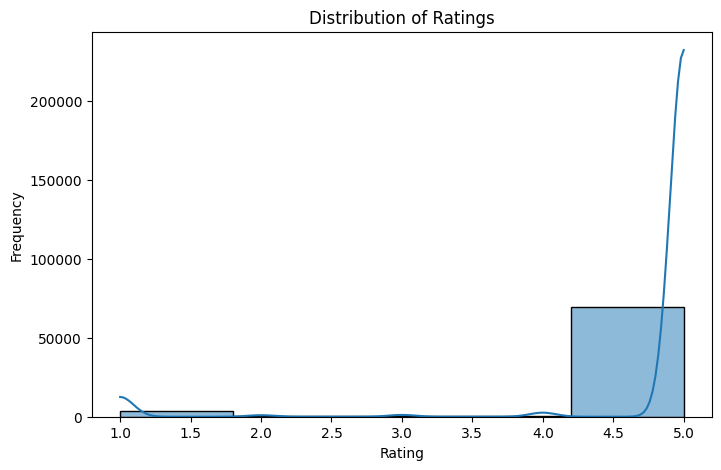

Skewness: -3.800436855401625


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=5,
    kde=True
)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

print("Skewness:", skew(df['Rating']))

**BIỂU ĐỒ 2 - PHÂN BỐ ĐỘ DÀI REVIEW**

In [ ]:
df['Review_Length'] = df['Review'].astype(str).str.len()

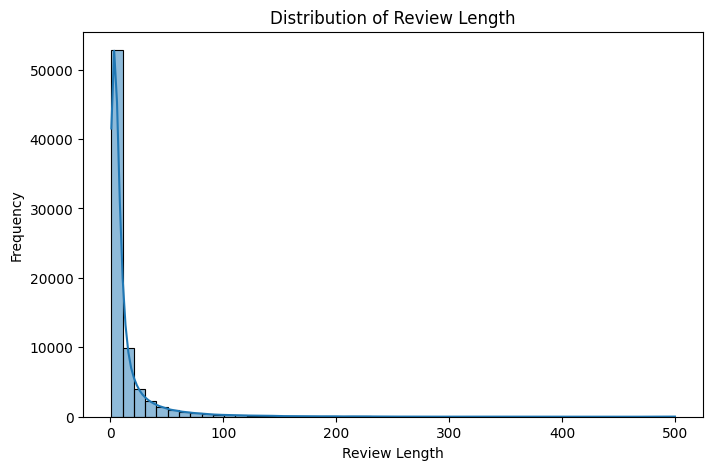

Skewness: 6.877298752855307


In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Review_Length'],
    bins=50,
    kde=True
)

plt.title('Distribution of Review Length')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.show()

print("Skewness:", skew(df['Review_Length']))

**BIỂU ĐỒ 3 - BOXPLOT ĐỘ DÀI REVIEW VỚI RATING**

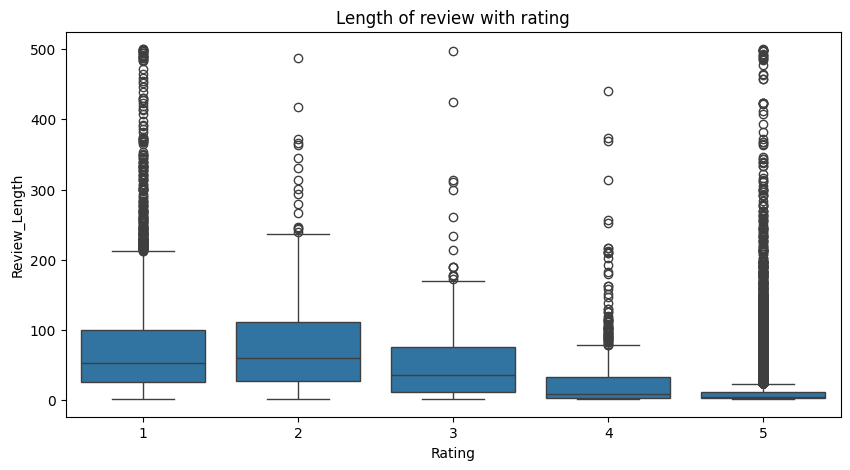

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Rating',
    y='Review_Length',
    data=df
)

plt.title('Length of review with rating')

plt.show()

## BIỂU ĐỒ 7 - SỐ LƯỢNG REVIEW THEO RATING

/tmp/ipykernel_4554/1822743769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


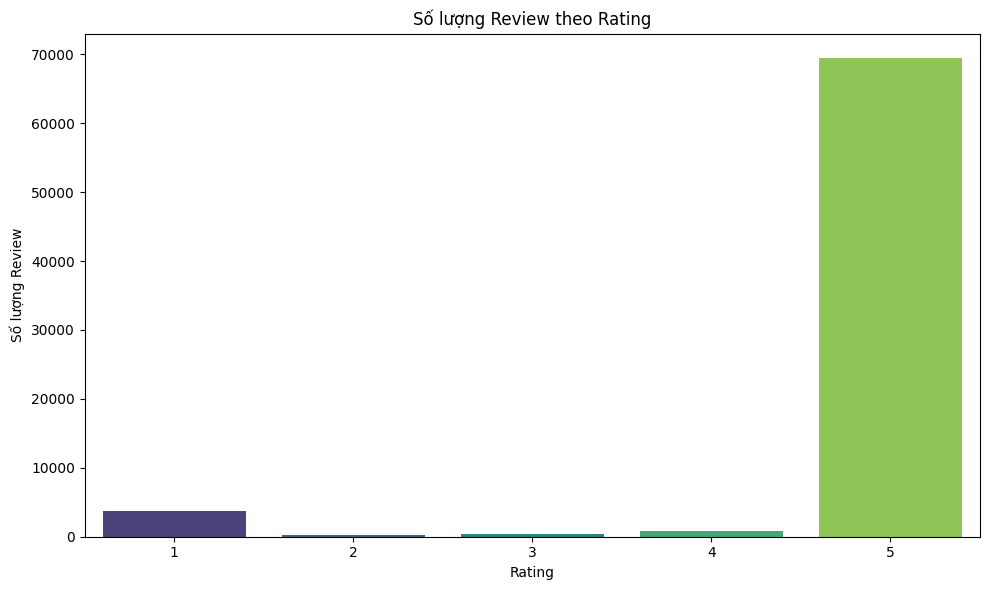

In [ ]:
plt.figure(figsize=(10, 6))

# Count the number of reviews for each rating
rating_counts = df['Rating'].value_counts().sort_index()

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette='viridis'
)

plt.title('Số lượng Review theo Rating')
plt.xlabel('Rating')
plt.ylabel('Số lượng Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**BIỂU ĐỒ 4 - SỐ LƯỢNG REVIEW THEO THỜI GIAN**


Tên cột hiện có:
Index(['User', 'Rating', 'Review', 'Date', 'Thumbs_Up', 'Reply_Count',
       'App_Version', 'Review_Id', 'Date_Only', 'Hour', 'Day_Name',
       'Review_Length'],
      dtype='object')


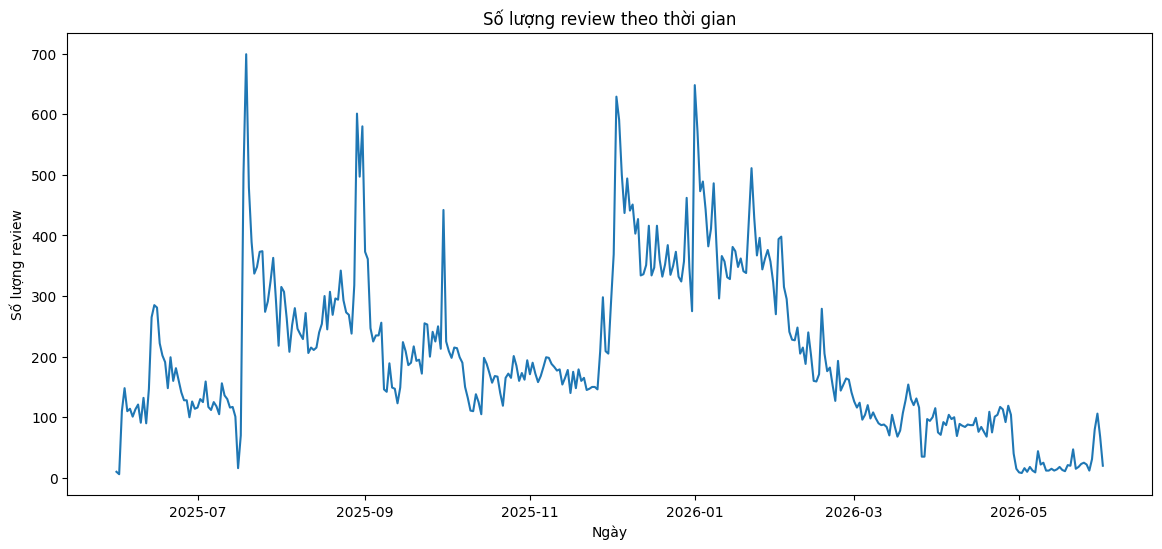

In [ ]:
print("\nTên cột hiện có:")
print(df.columns)
df['Date'] = pd.to_datetime(df['Date'])
reviews_by_date = df.groupby(df['Date'].dt.date).size()
plt.figure(figsize=(14,6))
reviews_by_date.plot()
plt.title('Số lượng review theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Số lượng review')
plt.show()

**BIỂU ĐỒ 5 - WORD CLOUND CHO REVIEW TIÊU CỰC**

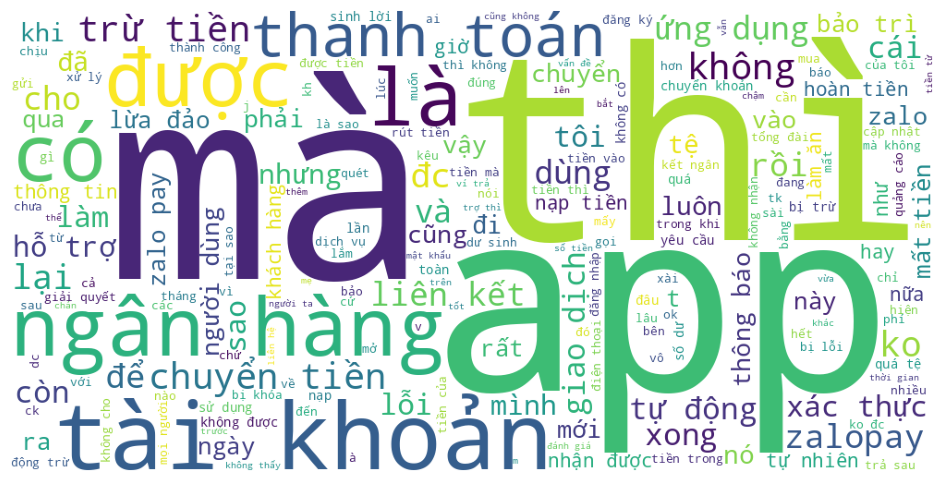

In [ ]:
from wordcloud import WordCloud

negative_text = " ".join(
    df[df['Rating'] <= 3]['Review'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

**BIỂU ĐỒ 6 - WORD CLOUND CHO REVIEW TÍCH CỰC**

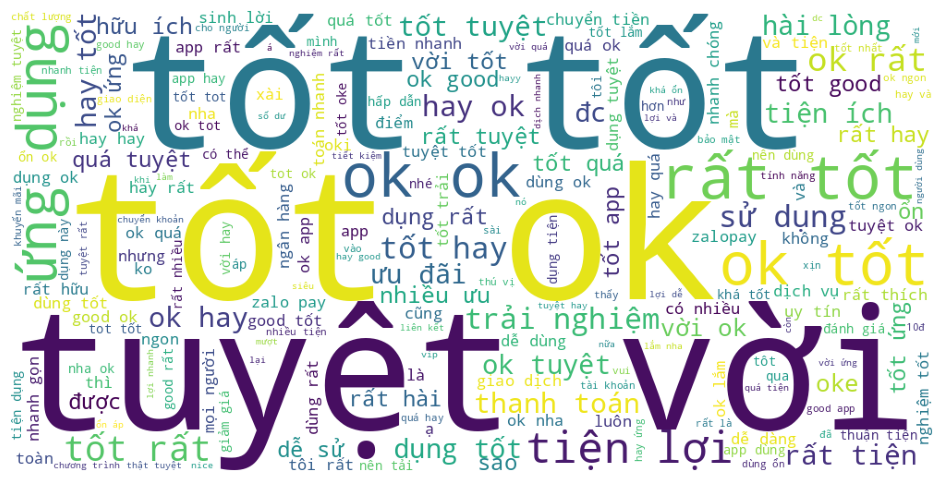

In [ ]:
positive_text = " ".join(
    df[df['Rating'] >= 4]['Review'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

---
## 3. Gán Nhãn (Label Assignment)
Chuyển đổi rating (1–5 sao) thành 4 mức độ nghiêm trọng.


In [ ]:
LABEL_NAMES = {
    0: "Bình thường",
    1: "Ít nghiêm trọng",
    2: "Nghiêm trọng",
    3: "Rất nghiêm trọng",
}

def assign_label(rating: int) -> int:
    """Rating → nhãn mức độ nghiêm trọng."""
    if rating == 1:   return 3
    elif rating == 2: return 2
    elif rating == 3: return 1
    else:             return 0    # 4, 5 sao

df["label"] = df["Rating"].apply(assign_label)

print("Phân phối nhãn:")
print(df["label"].map(LABEL_NAMES).value_counts().to_string())


Phân phối nhãn:
label
Bình thường         70256
Rất nghiêm trọng     3750
Ít nghiêm trọng       342
Nghiêm trọng          288


---
## 4. Tiền Xử Lý Văn Bản
Chuẩn hoá văn bản tiếng Việt cho PhoBERT.
> **Quan trọng:** Giữ nguyên dấu thanh và dấu phụ — PhoBERT được pre-train trên văn bản có dấu.


In [ ]:
# Teen code dictionary
TEEN_DICT = {
    "ko": "không",   "hok": "không",  "k": "không",   "kh": "không",
    "t":  "tao",     "dc":  "được",   "vs": "với",     "j":  "gì",
    "mk": "mật khẩu","mik": "mình",   "cx": "cũng",   "s":  "sao",
    "đag":"đang",    "ntn": "như thế nào","ok": "ổn",  "oke":"ổn",
    "tks":"cảm ơn",  "thx": "cảm ơn", "thanks":"cảm ơn",
    "sdt":"số điện thoại","ngta":"người ta","pv":"phục vụ",
    "cty":"công ty", "tk":  "tài khoản","dv":"dịch vụ",
    "bt": "biết",    "cskh":"chăm sóc khách hàng","tr":"triệu",
    "sd": "sử dụng", "z":   "vậy",    "dz":"vậy",     "ck":"chuyển khoản",
    "ng": "người",   "ms":  "mới",    "qa":"quá",     "nx":"nữa",
    "ap": "ứng dụng","v":   "vậy",    "cccd":"căn cước công dân",
    "lm": "làm",     "bth": "bình thường","nl":"nạp lại",
    "tl": "trả lời", "mn":  "mọi người","bn":"bạn",
    "bh": "bao giờ", "lắk": "lắm",    "vkl":"quá",    "vcl":"quá",
    "app":"ứng dụng","acc": "tài khoản","pass":"mật khẩu",
    "tuỵt zời":"tuyệt vời","tot":"tốt","Ô kê":"ổn", "cg": "cũng", "đc": "được"
}


def normalize_unicode(text: str) -> str:
    """Chuẩn hoá Unicode NFC — đồng nhất ký tự tiếng Việt."""
    return unicodedata.normalize("NFC", str(text))


def normalize_teencode(text: str) -> str:
    """Thay teen code bằng tiếng Việt chuẩn."""
    return " ".join(TEEN_DICT.get(w, w) for w in text.split())


def convert_emoji(text: str) -> str:
    """Chuyển emoji → mô tả văn bản (giữ sentiment).
    Ví dụ: 😡 → ':enraged_face:'
    """
    return emoji.demojize(text)


def clean_text(text: str) -> str:
    """Xoá URL, HTML tags, ký tự lặp thừa; chuẩn hoá khoảng trắng."""
    text = re.sub(r"http\S+|www\S+", "", text)           # URL
    text = re.sub(r"<[^>]+>", "", text)                    # HTML
    text = re.sub(r"([^\wÀ-ỹ])\1{2,}", r"\1\1", text)   # ký tự lặp
    return re.sub(r"\s+", " ", text).strip()


def preprocess_for_phobert(text: str) -> str:
    """Pipeline tiền xử lý đầy đủ cho PhoBERT."""
    text = normalize_unicode(text)
    text = clean_text(text)
    text = normalize_teencode(text)
    text = convert_emoji(text)
    return text


print("Định nghĩa các hàm tiền xử lý thành công!")


Định nghĩa các hàm tiền xử lý thành công!


In [ ]:
print("Tiền xử lý văn bản")
df["text_clean"] = df["Review"].apply(preprocess_for_phobert)

print("Word tokenize")
df["text_for_phobert"] = df["text_clean"].progress_apply(
    lambda x: word_tokenize(str(x), format="text")
)

# Kiểm tra kết quả
idx = 0
print(f"  Review gốc       : {df['Review'].iloc[idx]}")
print(f"  Sau clean        : {df['text_clean'].iloc[idx]}")
print(f"  Sau word_tokenize: {df['text_for_phobert'].iloc[idx]}")


Tiền xử lý văn bản
Word tokenize


100%|██████████| 74636/74636 [00:13<00:00, 5360.90it/s]

  Review gốc       : oke
  Sau clean        : ổn
  Sau word_tokenize: ổn


In [ ]:
# Lọc review rỗng
df = (
    df[df["text_for_phobert"].str.strip().str.len() > 0]
    .dropna(subset=["text_for_phobert"])
    .reset_index(drop=True)
)
# Kiểm tra số lượng Review bị trùng lặp
duplicate_ids = df.duplicated(subset=['Review_Id']).sum()
print(f"Số lượng Review_Id bị trùng lặp: {duplicate_ids}")

Số lượng Review_Id bị trùng lặp: 0


In [ ]:
df.to_excel("data_prepared.xlsx", index=False)
print("Đã lưu dữ liệu đã tiền xử lý → data_prepared.xlsx")


Đã lưu dữ liệu đã tiền xử lý → data_prepared.xlsx
